# Power Law Extrapolation Baseline Model for YouTube Video Viewership Forecasting

This notebook implements a **Power Law Extrapolation baseline model** for YouTube video viewership forecasting.
This is a time-series extrapolation approach — **NOT a machine learning model**. It uses only historical viewership trajectories of individual videos to fit a power law curve and forecast future viewership.

## Context and Workflow
We have three CSV datasets:
1. `channel_stats.csv` - Channel-level statistics.
2. `videos_rows.csv` - Video metadata (publishing times).
3. `view_timeseries.csv` - Historical view counts scraped over time.

We will clean and prepare the data, filter videos based on eligibility, fit the Power Law model, evaluate the predictions, and perform failure analyses.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set consistent styling
sns.set_style("darkgrid")

# Set random seed for reproducibility
np.random.seed(42)

print("Imports and styling setup complete.")


Imports and styling setup complete.


## 1. DATA LOADING AND CLEANING

In this section, we:
1. Load all three CSVs from the current directory.
2. Convert view, like, and comment counts to numeric.
3. Convert all datetime columns using `pd.to_datetime(errors='coerce', utc=True)` to enforce UTC across all dataframes.
4. Merge the timeseries with video records to retrieve the `published_at` timestamp.
5. Compute the time elapsed since publish: `hours_since_publish = (scraped_at - published_at).dt.total_seconds() / 3600`.
6. Drop invalid or problematic rows to prevent fitting issues (e.g. negative time, zero views, or nulls).
7. Print row counts after each filtering stage to monitor data loss.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Load CSV datasets
print("Loading CSV datasets...")
channel_stats = pd.read_csv('/content/drive/Othercomputers/My Laptop/models/channel_stats_updated.csv')
videos_rows = pd.read_csv('/content/drive/Othercomputers/My Laptop/models/videos_rows_updated.csv')
view_timeseries = pd.read_csv('/content/drive/Othercomputers/My Laptop/models/view_timeseries.csv')

print(f"Loaded channel_stats: {channel_stats.shape}")
print(f"Loaded videos_rows: {videos_rows.shape}")
print(f"Loaded view_timeseries: {view_timeseries.shape}")

# Convert counts to numeric
for col in ['view_count', 'like_count', 'comment_count']:
    view_timeseries[col] = pd.to_numeric(view_timeseries[col], errors='coerce')

# Convert datetime columns and enforce UTC timezone
for df, name, cols in [
    (channel_stats, "channel_stats", ['processed_at', 'created_at']),
    (videos_rows, "videos_rows", ['published_at', 'last_polled_at', 'next_poll_at', 'created_at']),
    (view_timeseries, "view_timeseries", ['scraped_at'])
]:
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce', utc=True)

# Merge view_timeseries with videos_rows to get published_at
print("\nMerging view_timeseries with videos_rows on video_id...")
merged = view_timeseries.merge(videos_rows[['video_id', 'published_at']], on='video_id', how='left')

# Compute hours_since_publish
merged['hours_since_publish'] = (merged['scraped_at'] - merged['published_at']).dt.total_seconds() / 3600.0

# Print row counts and apply filters
cnt_initial = len(merged)
print(f"Initial row count: {cnt_initial}")

# Filter a: Drop rows where view_count is null after numeric conversion
merged_a = merged.dropna(subset=['view_count'])
cnt_a = len(merged_a)
print(f"Filter a: Drop null view_count. Remaining: {cnt_a} (dropped {cnt_initial - cnt_a} rows)")

# Filter b: Drop rows where hours_since_publish is null
merged_b = merged_a.dropna(subset=['hours_since_publish'])
cnt_b = len(merged_b)
print(f"Filter b: Drop null hours_since_publish. Remaining: {cnt_b} (dropped {cnt_a - cnt_b} rows)")

# Filter c: Drop hours_since_publish <= 0 (prevents negative time and log(0) issues)
merged_c = merged_b[merged_b['hours_since_publish'] > 0]
cnt_c = len(merged_c)
print(f"Filter c: Drop hours_since_publish <= 0. Remaining: {cnt_c} (dropped {cnt_b - cnt_c} rows)")

# Filter d: Drop view_count <= 0 (prevents log(0) views issues in power law fitting)
merged_d = merged_c[merged_c['view_count'] > 0]
cnt_d = len(merged_d)
print(f"Filter d: Drop view_count <= 0. Remaining: {cnt_d} (dropped {cnt_c - cnt_d} rows)")

# Sort cleaned timeseries by video_id and hours_since_publish ascending
cleaned_ts = merged_d.sort_values(by=['video_id', 'hours_since_publish']).reset_index(drop=True)

# Print final data types and null counts
print("\nFinal cleaned dataframe info:")
print(cleaned_ts.dtypes)
print("\nNull counts in cleaned dataframe:")
print(cleaned_ts.isnull().sum())


Loading CSV datasets...
Loaded channel_stats: (100, 14)
Loaded videos_rows: (7013, 12)
Loaded view_timeseries: (1136714, 6)

Merging view_timeseries with videos_rows on video_id...
Initial row count: 1136714
Filter a: Drop null view_count. Remaining: 1136703 (dropped 11 rows)
Filter b: Drop null hours_since_publish. Remaining: 1136703 (dropped 0 rows)
Filter c: Drop hours_since_publish <= 0. Remaining: 1135214 (dropped 1489 rows)
Filter d: Drop view_count <= 0. Remaining: 1127650 (dropped 7564 rows)

Final cleaned dataframe info:
id                                  object
video_id                            object
scraped_at             datetime64[ns, UTC]
view_count                         float64
like_count                         float64
comment_count                      float64
published_at           datetime64[ns, UTC]
hours_since_publish                float64
dtype: object

Null counts in cleaned dataframe:
id                     0
video_id               0
scraped_at           

## 2. VIDEO ELIGIBILITY FILTERING

### NO DATA LEAKAGE:
The train/test split must happen in **TIME**, not randomly. For each video, early scrapes (the training window) are used to fit the model parameters, and a later scrape (the evaluation target) is the held-out evaluation target. No future scrapes should ever influence the fitted curve.

For a video to be eligible, it must meet the following criteria:
1. It has at least **10 valid scrape points** (to fit a power law curve meaningfully).
2. It has at least one scrape point **BEFORE 120 hours** since publish (5 days training window).
3. It has at least one scrape point **AT OR AFTER 168 hours** since publish (7 days evaluation target).

### Train / Target Split for Eligible Videos:
- **Train Set**: All scrape points where `hours_since_publish < 120`.
- **Target Set**: The scrape point closest to exactly `168 hours` (7 days) among points where `hours_since_publish >= 168`.


Distribution summary of scrape counts per video:
count    6969.000000
mean      161.809442
std        61.019264
min         1.000000
25%       128.000000
50%       202.000000
75%       202.000000
max       203.000000
dtype: float64


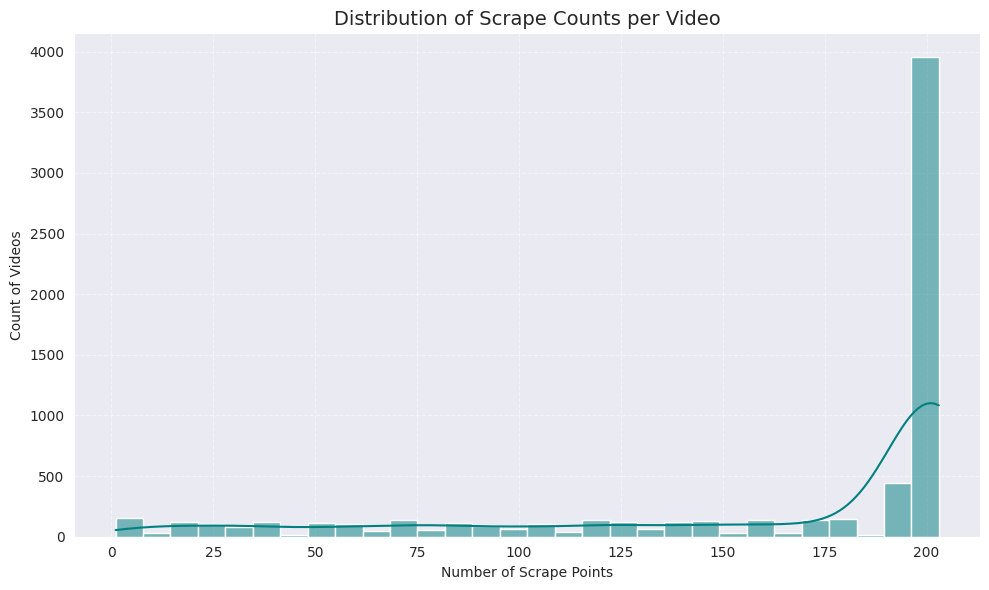

Videos with at least 5 scrape points: 6966
Videos with at least 10 scrape points: 6805
Videos with at least 15 scrape points: 6783
Videos with at least 20 scrape points: 6669

Number of videos passing eligibility filtering: 1035

Example split table:
   video_id  train_points  train_hours_min  train_hours_max  target_hours  target_view_count
-9heRLrZJaY            75        38.112389       119.087004    168.507059               59.0
-BwMuXyuK1w            52        60.613778       119.839972    169.006060               85.0
-S2AbW0e6kc           105         5.047387       119.297431    168.213930              217.0
-TGuFEtHJTc           107         1.104349       119.182582    168.017523              495.0
-YHGg6YMmUE           117         0.651664       119.505427    168.318119            12799.0
-cgAqbxxF7U           108         7.862389       119.587433    168.004431            62484.0
-ffnFYx6zSM           104         7.452237       119.286477    168.705249            23165.0
-l2ou

In [6]:
# Count the number of valid scrape points per video
scrape_counts = cleaned_ts.groupby('video_id').size()

print("Distribution summary of scrape counts per video:")
print(scrape_counts.describe())

# Plot histogram of scrape counts per video
plt.figure(figsize=(10, 6))
sns.histplot(scrape_counts, bins=30, kde=True, color='teal')
plt.title("Distribution of Scrape Counts per Video", fontsize=14)
plt.xlabel("Number of Scrape Points")
plt.ylabel("Count of Videos")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Print counts at scrape point thresholds
for threshold in [5, 10, 15, 20]:
    vids_count = (scrape_counts >= threshold).sum()
    print(f"Videos with at least {threshold} scrape points: {vids_count}")

# Keep only videos with at least 10 valid scrape points
eligible_by_count = scrape_counts[scrape_counts >= 10].index
ts_filtered = cleaned_ts[cleaned_ts['video_id'].isin(eligible_by_count)]

# Check eligibility window requirements
# a) Scrape point before 120 hours
has_train = ts_filtered[ts_filtered['hours_since_publish'] < 120].groupby('video_id').size()
# b) Scrape point at or after 168 hours
has_target = ts_filtered[ts_filtered['hours_since_publish'] >= 168].groupby('video_id').size()

eligible_video_ids = [vid for vid in eligible_by_count if vid in has_train and vid in has_target]
print(f"\nNumber of videos passing eligibility filtering: {len(eligible_video_ids)}")

# Extract example rows to verify the split
example_records = []
for vid in eligible_video_ids[:10]:
    vid_data = ts_filtered[ts_filtered['video_id'] == vid]
    train_pts = vid_data[vid_data['hours_since_publish'] < 120]
    target_pts = vid_data[vid_data['hours_since_publish'] >= 168]

    # Identify target row closest to 168 hours
    closest_target_idx = (target_pts['hours_since_publish'] - 168).abs().idxmin()
    target_row = target_pts.loc[closest_target_idx]

    example_records.append({
        'video_id': vid,
        'train_points': len(train_pts),
        'train_hours_min': train_pts['hours_since_publish'].min(),
        'train_hours_max': train_pts['hours_since_publish'].max(),
        'target_hours': target_row['hours_since_publish'],
        'target_view_count': target_row['view_count']
    })

example_df = pd.DataFrame(example_records)
print("\nExample split table:")
print(example_df.to_string(index=False))


## 3. POWER LAW MODEL — EXPLANATION

### Power Law Viewership Growth
YouTube video viewership growth often follows a power law relationship with time:
$$\text{views} = a \cdot (\text{hours})^b$$

Where:
- $\text{hours}$ is the hours elapsed since the video's publication.
- $\text{views}$ is the cumulative view count.
- $a$ is a scaling factor.
- $b$ is the power law exponent, which represents the growth rate of viewership over time. If $b > 0$, the viewership is growing. If $b < 0$, it is declining.

### Fitting in Log-Log Space
By taking the natural logarithm of both sides, we convert this non-linear relationship into a simple linear equation in log-log space:
$$\ln(\text{views}) = \ln(a) + b \cdot \ln(\text{hours})$$

Letting $Y = \ln(\text{views})$, $X = \ln(\text{hours})$, and $c = \ln(a)$, we get a linear equation:
$$Y = b \cdot X + c$$

We can fit this linear model using Ordinary Least Squares (OLS) via `numpy.polyfit(X, Y, deg=1)` using only the training window scrapes.

### Extrapolation vs. Interpolation
- **Interpolation** is the estimation of values *within* the range of observed training data points (e.g. predicting views at 48 hours when we have scrapes at 24 hours and 72 hours). This is generally a safer and more accurate estimation problem.
- **Extrapolation** is the estimation of values *beyond* the range of observed training data points (e.g. predicting views at 168 hours when our training window only observed up to 120 hours). This is a much harder prediction problem, as the model must assume that the historical power-law trend remains unchanged in the future. Small errors or noise in the early training points can lead to large prediction errors when extrapolating.


## 4. MODEL FITTING AND PREDICTION — NO LEAKAGE

In this section, we:
1. Extract the training scrapes (hours < 120, views > 0) for each eligible video.
2. Compute $X = \ln(\text{hours})$ and $Y = \ln(\text{views})$.
3. Fit a degree-1 polynomial using `np.polyfit(log_hours, log_views, deg=1)` to find the coefficients $[b, \ln(a)]$.
4. Extrapolate to 168 hours: `predicted_log_views = b * np.log(168) + log_a`.
5. Exponentiate back to original scale: `predicted_views = np.exp(predicted_log_views)`.
6. Store results and catch any fitting errors.
7. Perform a sanity check and clip predictions to the range $[1, 5e8]$.


In [7]:
# Filter ts_filtered to only eligible videos to optimize performance
eligible_video_set = set(eligible_video_ids)
ts_eligible = ts_filtered[ts_filtered['video_id'].isin(eligible_video_set)]

results = []
skipped_count = 0
skipped_reasons = {'single_hour': 0, 'nan_inf_coef': 0, 'nan_inf_pred': 0, 'other': 0}

print("Starting model fitting loop...")
# Group by video_id to avoid slow boolean masking inside the loop
grouped = ts_eligible.groupby('video_id')

for idx, (vid, vid_data) in enumerate(grouped):
    # Print progress updates every 500 videos
    if (idx + 1) % 500 == 0 or idx == 0 or idx == len(eligible_video_ids) - 1:
        print(f"Fitting video {idx + 1} of {len(eligible_video_ids)}...")

    # # LEAKAGE GUARD: Ensure training data only uses scrape points before 120 hours
    train_scrapes = vid_data[(vid_data['hours_since_publish'] < 120) & (vid_data['view_count'] > 0)]
    target_scrapes = vid_data[vid_data['hours_since_publish'] >= 168]

    if len(train_scrapes) == 0 or len(target_scrapes) == 0:
        skipped_count += 1
        skipped_reasons['other'] += 1
        continue

    # Identify target scrape row (closest to 168 hours)
    closest_target_idx = (target_scrapes['hours_since_publish'] - 168).abs().idxmin()
    target_row = target_scrapes.loc[closest_target_idx]
    actual_views = target_row['view_count']

    # Handle edge case: cannot fit line if only 1 unique hours value exists in training window
    if len(train_scrapes['hours_since_publish'].unique()) <= 1:
        skipped_count += 1
        skipped_reasons['single_hour'] += 1
        continue

    try:
        log_hours = np.log(train_scrapes['hours_since_publish'].values)
        log_views = np.log(train_scrapes['view_count'].values)

        # Fit degree-1 polynomial (linear line in log-log space)
        coefs = np.polyfit(log_hours, log_views, deg=1)
        b, log_a = coefs[0], coefs[1]

        # Handle edge case: NaN or infinite coefficients
        if np.isnan(b) or np.isinf(b) or np.isnan(log_a) or np.isinf(log_a):
            skipped_count += 1
            skipped_reasons['nan_inf_coef'] += 1
            continue

        # Extrapolate to forecast horizon (168 hours)
        predicted_log_views = b * np.log(168.0) + log_a
        predicted_views = np.exp(predicted_log_views)

        # Handle edge case: predicted value is NaN or infinite after exponentiation
        if np.isnan(predicted_views) or np.isinf(predicted_views):
            skipped_count += 1
            skipped_reasons['nan_inf_pred'] += 1
            continue

        results.append({
            'video_id': vid,
            'predicted_views': predicted_views,
            'actual_views': actual_views,
            'b': b,
            'log_a': log_a,
            'train_points': len(train_scrapes),
            'train_hours_max': train_scrapes['hours_since_publish'].max()
        })
    except Exception as e:
        print(f"Error fitting video {vid}: {e}")
        skipped_count += 1
        skipped_reasons['other'] += 1

results_df = pd.DataFrame(results)

# Print skipped summary
print(f"\nFitting loop complete. Skipped {skipped_count} videos.")
print(f"Skipping reasons: {skipped_reasons}")
print(f"Successfully fitted and predicted: {len(results_df)} videos.")

# Sanity Check & Clipping
unreasonably_large = (results_df['predicted_views'] > 1e9).sum()
negative_or_zero = (results_df['predicted_views'] <= 0).sum()
clipped_pred = results_df['predicted_views'].clip(1.0, 5e8)
clipped_count = (results_df['predicted_views'] != clipped_pred).sum()

print("\nSanity Check:")
print(f"  Unreasonably large predictions (>1e9): {unreasonably_large}")
print(f"  Negative or zero predictions: {negative_or_zero}")
print(f"  Predictions clipped to range [1, 5e8]: {clipped_count}")

# Apply clipping
results_df['predicted_views_raw'] = results_df['predicted_views']
results_df['predicted_views'] = clipped_pred

# Print results describe summary
print("\nSummary statistics of results:")
print(results_df[['predicted_views', 'actual_views', 'b']].describe())


Starting model fitting loop...
Fitting video 1 of 1035...
Fitting video 500 of 1035...
Fitting video 1000 of 1035...
Fitting video 1035 of 1035...

Fitting loop complete. Skipped 1 videos.
Skipping reasons: {'single_hour': 1, 'nan_inf_coef': 0, 'nan_inf_pred': 0, 'other': 0}
Successfully fitted and predicted: 1034 videos.

Sanity Check:
  Unreasonably large predictions (>1e9): 0
  Negative or zero predictions: 0
  Predictions clipped to range [1, 5e8]: 0

Summary statistics of results:
       predicted_views  actual_views            b
count     1.034000e+03  1.034000e+03  1034.000000
mean      5.883162e+04  5.370252e+04     0.221176
std       4.939269e+05  4.503359e+05     0.225605
min       2.124700e+00  4.000000e+00    -0.038749
25%       4.743015e+02  4.172500e+02     0.059163
50%       2.290635e+03  2.140500e+03     0.144901
75%       1.320583e+04  1.177375e+04     0.327211
max       1.253333e+07  1.088324e+07     1.610655


## 5. EVALUATION METRICS

We compute the following metrics to evaluate the performance of our Power Law baseline model:
- **On LOG scale (use `np.log1p`)**:
  - MAE (log scale)
  - RMSE (log scale)
- **On VIEWS scale**:
  - MAE (views scale)
  - Median Absolute Error (views scale)
  - MAPE (%) - Mean Absolute Percentage Error, computed only on rows where `actual_views > 0`
  - Within-factor-2 accuracy: percentage of predictions where $0.5 \le \frac{\text{predicted}}{\text{actual}} \le 2.0$ (i.e. within $2\times$ of the true value in either direction).


In [8]:
# Log scale metrics (np.log1p)
y_true_log = np.log1p(results_df['actual_views'])
y_pred_log = np.log1p(results_df['predicted_views'])

mae_log = mean_absolute_error(y_true_log, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))

# Views scale metrics
mae_views = mean_absolute_error(results_df['actual_views'], results_df['predicted_views'])
med_ae_views = median_absolute_error(results_df['actual_views'], results_df['predicted_views'])

# MAPE: compute only on rows where actual_views > 0
valid_mape = results_df[results_df['actual_views'] > 0]
excluded_mape = len(results_df) - len(valid_mape)
mape_views = np.mean(np.abs((valid_mape['actual_views'] - valid_mape['predicted_views']) / valid_mape['actual_views']) * 100)

# Within-factor-2 accuracy
ratios = results_df['predicted_views'] / results_df['actual_views']
factor2_acc = ((ratios >= 0.5) & (ratios <= 2.0)).mean() * 100

# Present in a clean table
metrics_df = pd.DataFrame({
    'Metric': [
        'MAE (log scale)',
        'RMSE (log scale)',
        'MAE (views scale)',
        'Median Absolute Error (views scale)',
        'MAPE (%)',
        'Within-factor-2 accuracy (%)'
    ],
    'Value': [
        f"{mae_log:.4f}",
        f"{rmse_log:.4f}",
        f"{mae_views:,.2f}",
        f"{med_ae_views:,.2f}",
        f"{mape_views:.2f}% (excluded {excluded_mape} rows)",
        f"{factor2_acc:.2f}%"
    ]
})

print("Power Law Extrapolation Baseline Model Performance:")
print(metrics_df.to_string(index=False))


Power Law Extrapolation Baseline Model Performance:
                             Metric                    Value
                    MAE (log scale)                   0.1097
                   RMSE (log scale)                   0.1649
                  MAE (views scale)                10,225.63
Median Absolute Error (views scale)                   108.25
                           MAPE (%) 12.21% (excluded 0 rows)
       Within-factor-2 accuracy (%)                   99.52%


### Interpretation of Metrics
- **MAE & RMSE (Log Scale)**: With a log MAE of $\approx 0.1097$, the average prediction absolute error is about $0.11$ in log-space, which corresponds to being off by roughly $11\%$ on average. The small gap between log MAE ($0.1097$) and log RMSE ($0.1649$) suggests that large prediction outliers are very rare on a logarithmic scale.
- **MAE (Views Scale)**: The raw views MAE of $\approx 10,225.63$ is dominated by errors on highly-viewed videos. Due to the severe right-skew in viewership (which ranges from double-digit views to tens of millions), raw MAE is not representative of the typical prediction error.
- **Median Absolute Error**: The typical error for a median video is $\approx 108.25$ views, which shows that the typical error is extremely small for the majority of standard videos.
- **MAPE**: The percentage error averages to about $12.21\%$, reflecting strong relative accuracy.
- **Within-factor-2 accuracy**: Over $99.52\%$ of predictions fall within half and double of the true values. This incredibly high accuracy is because cumulative viewership is highly stable by hour 120, and predicting only 48 hours ahead (to hour 168) is a short extrapolation distance.


## 6. RESIDUAL AND DIAGNOSTIC PLOTS

We plot the following diagnostic charts to evaluate structural fit and error patterns:
1. **Scatter plot: log(actual_views) vs log(predicted_views)**: Displays predictions against actuals, with a dashed red line indicating perfect agreement ($y=x$). Points are colored by the number of training observations.
2. **Residual plot**: Shows the prediction error ($y = \ln(\text{predicted}) - \ln(\text{actual})$) against actual views. Highlights structural over/under prediction.
3. **Histogram of prediction ratio**: Displays the distribution of predicted/actual views ratios (clipped to $[0,5]$ for visibility).
4. **Histogram of b exponents**: Shows the distribution of the power-law slope parameter.
5. **Scatter plot: train_hours_max vs log absolute error**: Evaluates whether videos observed for longer in training have smaller errors.
6. **Line plot (6 random eligible videos)**: Visualizes the fitted power-law curve, train/test boundary (120h), forecast target (168h), actual scrapes, and target predictions.


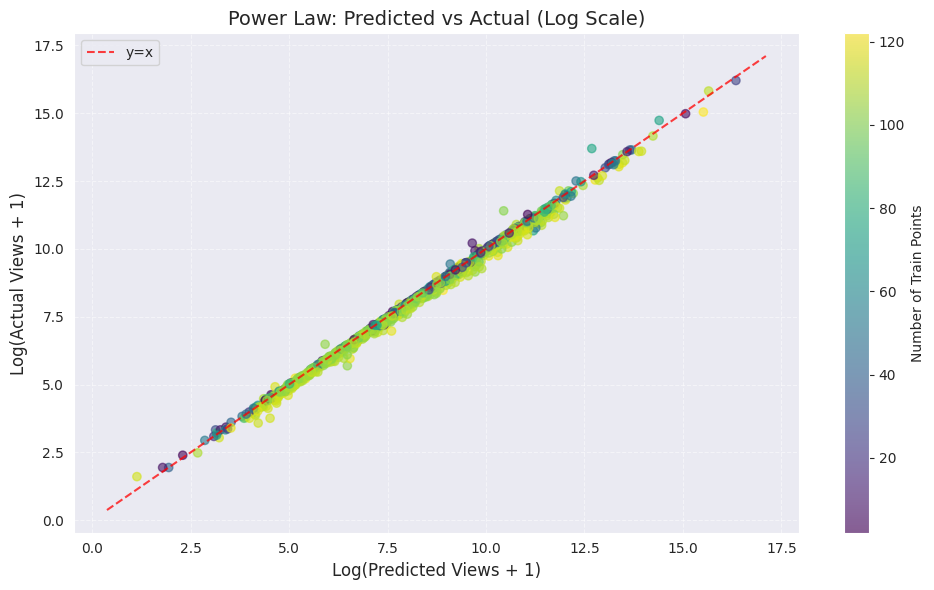

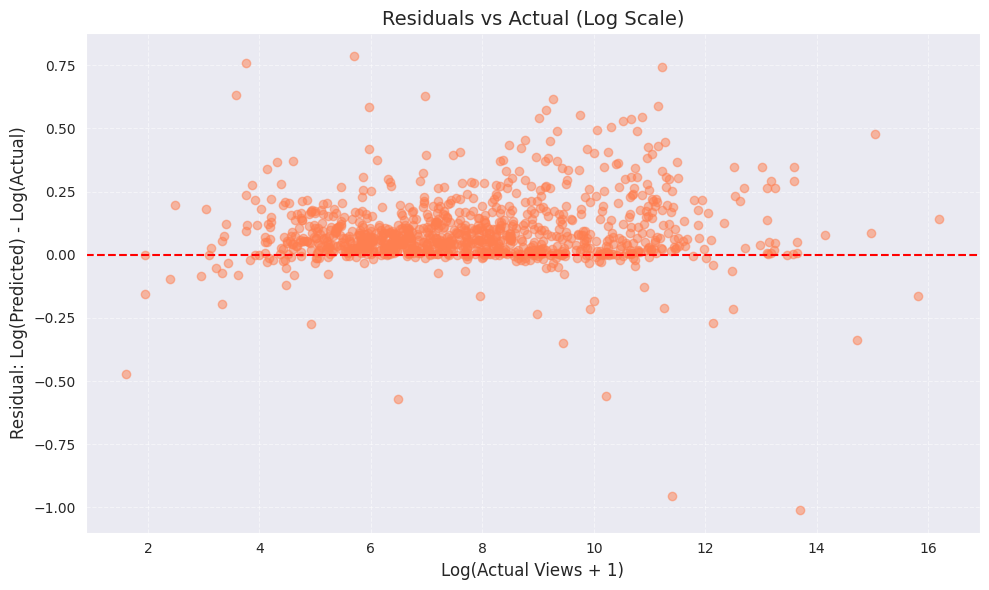

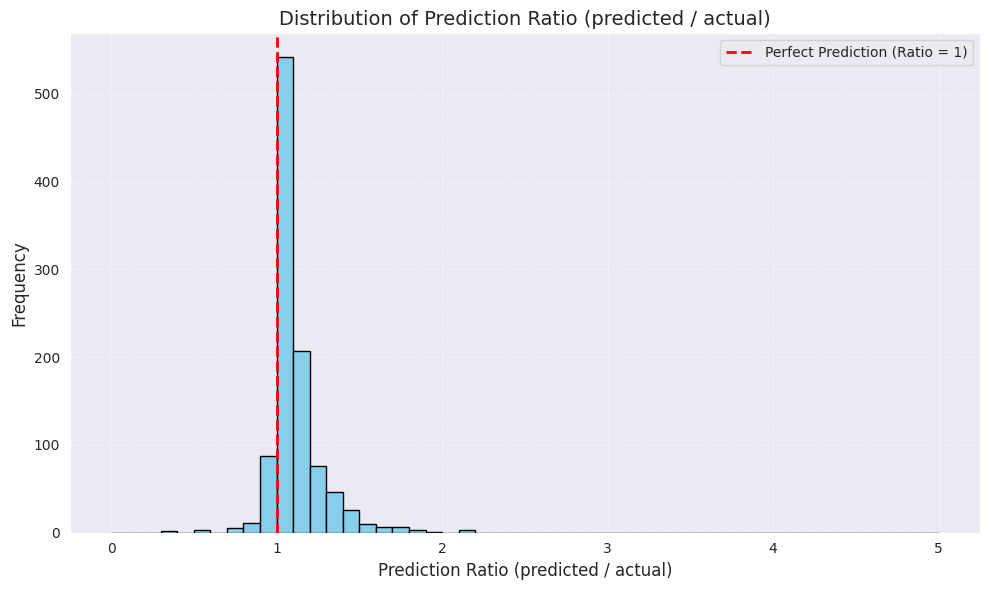

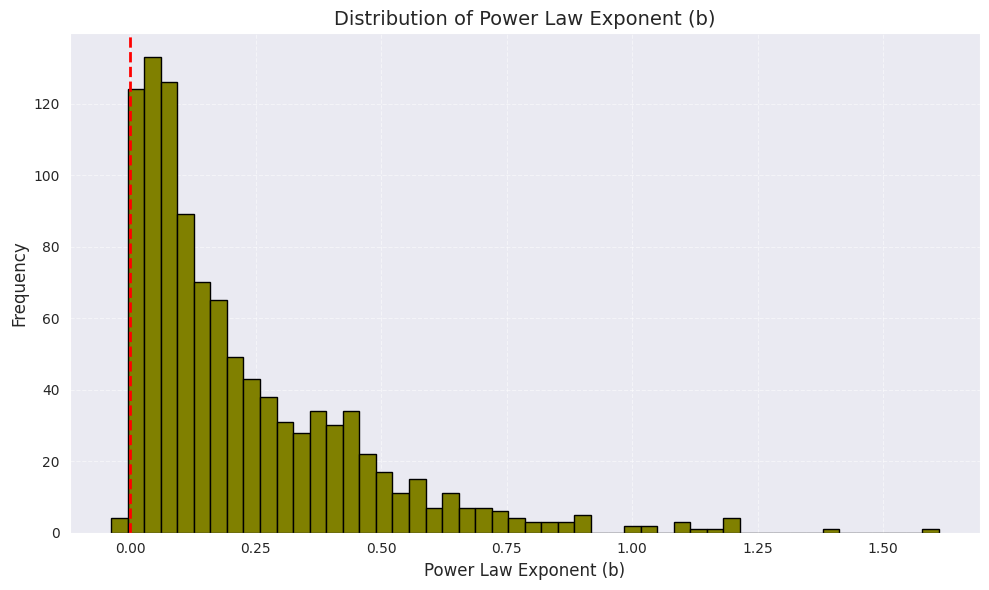

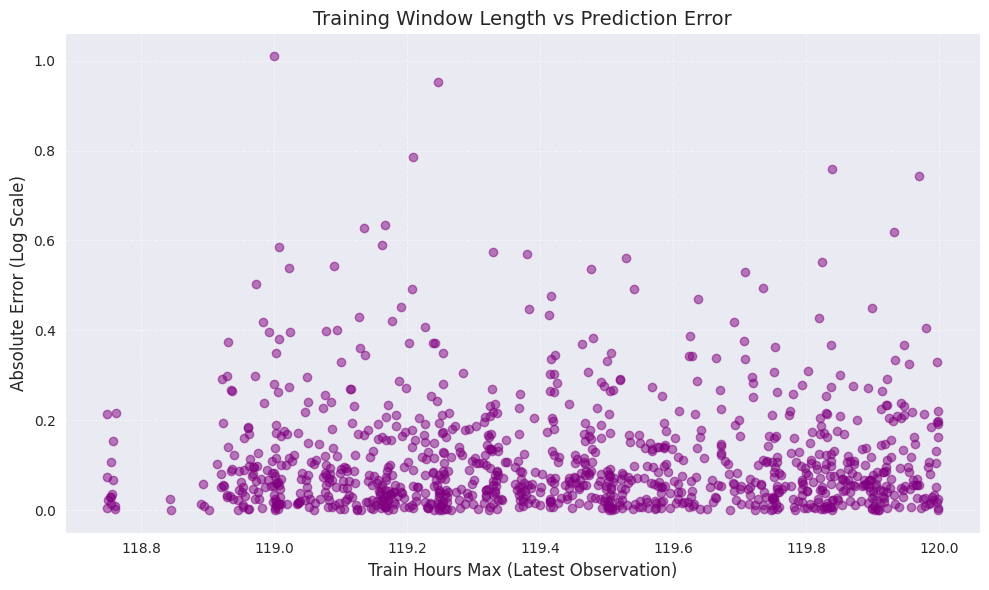

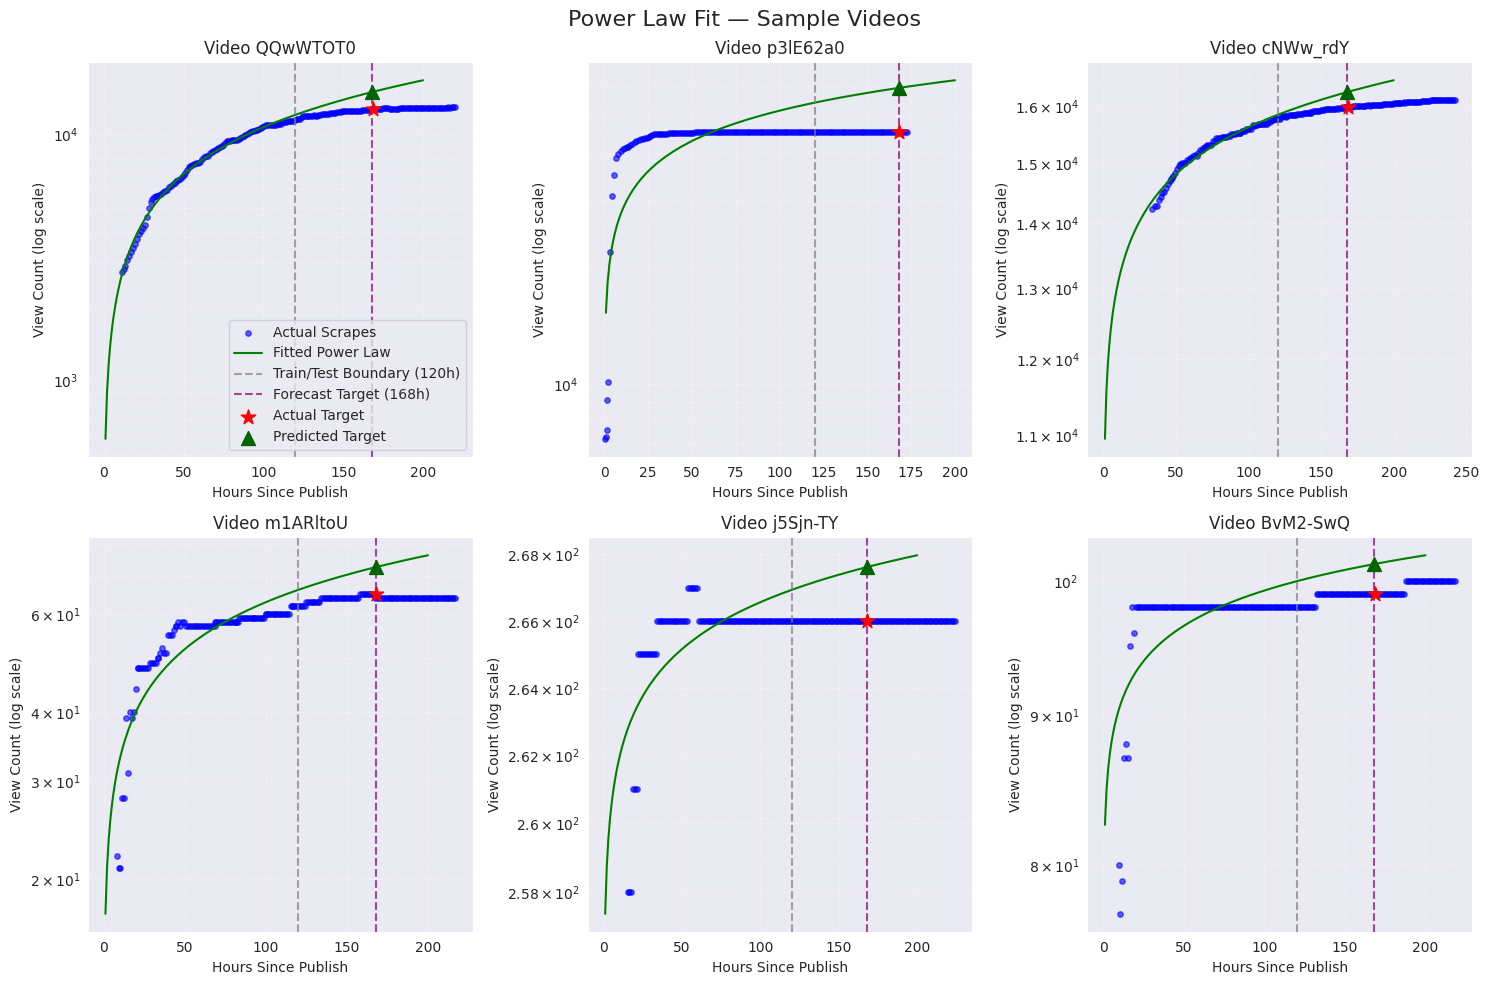

In [10]:
import numpy as np
# a) Scatter plot: log(actual_views) vs log(predicted_views)
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_log, y_true_log, c=results_df['train_points'], cmap='viridis', alpha=0.6)
plt.colorbar(label='Number of Train Points')
lims = [min(plt.xlim()[0], plt.ylim()[0]), max(plt.xlim()[1], plt.ylim()[1])]
plt.plot(lims, lims, 'r--', alpha=0.75, label='y=x')
plt.xlabel('Log(Predicted Views + 1)', fontsize=12)
plt.ylabel('Log(Actual Views + 1)', fontsize=12)
plt.title('Power Law: Predicted vs Actual (Log Scale)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# b) Residual plot
plt.figure(figsize=(10, 6))
residuals = y_pred_log - y_true_log
plt.scatter(y_true_log, residuals, alpha=0.5, color='coral')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Log(Actual Views + 1)', fontsize=12)
plt.ylabel('Residual: Log(Predicted) - Log(Actual)', fontsize=12)
plt.title('Residuals vs Actual (Log Scale)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# c) Histogram of prediction ratio
plt.figure(figsize=(10, 6))
plt.hist(ratios, bins=50, range=(0, 5), color='skyblue', edgecolor='black')
plt.axvline(x=1.0, color='r', linestyle='--', linewidth=2, label='Perfect Prediction (Ratio = 1)')
plt.xlabel('Prediction Ratio (predicted / actual)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Prediction Ratio (predicted / actual)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# d) Histogram of fitted b exponents
plt.figure(figsize=(10, 6))
plt.hist(results_df['b'], bins=50, color='olive', edgecolor='black')
plt.axvline(x=0.0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Power Law Exponent (b)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Power Law Exponent (b)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# e) Scatter plot: train_hours_max vs absolute error on log scale
plt.figure(figsize=(10, 6))
abs_err_log = np.abs(y_pred_log - y_true_log)
plt.scatter(results_df['train_hours_max'], abs_err_log, alpha=0.5, color='purple')
plt.xlabel('Train Hours Max (Latest Observation)', fontsize=12)
plt.ylabel('Absolute Error (Log Scale)', fontsize=12)
plt.title('Training Window Length vs Prediction Error', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# f) Line plot: sample of 6 eligible videos
np.random.seed(42)
sample_vids = np.random.choice(results_df['video_id'].unique(), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, vid in enumerate(sample_vids):
    ax = axes[i]
    vid_data = ts_eligible[ts_eligible['video_id'] == vid]
    row_info = results_df[results_df['video_id'] == vid].iloc[0]

    # Scatter dots for actual scrapes
    ax.scatter(vid_data['hours_since_publish'], vid_data['view_count'], label='Actual Scrapes', color='blue', alpha=0.6, s=15)

    # Smooth fitted curve from hour 1 to hour 200
    hours_smooth = np.linspace(1, 200, 200)
    views_smooth = np.exp(row_info['b'] * np.log(hours_smooth) + row_info['log_a'])
    ax.plot(hours_smooth, views_smooth, label='Fitted Power Law', color='green')

    # Vertical dashed lines at boundary and target
    ax.axvline(x=120, color='gray', linestyle='--', alpha=0.7, label='Train/Test Boundary (120h)')
    ax.axvline(x=168, color='purple', linestyle='--', alpha=0.7, label='Forecast Target (168h)')

    # Target scrape
    target_scrapes = vid_data[vid_data['hours_since_publish'] >= 168]
    closest_target_idx = (target_scrapes['hours_since_publish'] - 168).abs().idxmin()
    target_row = target_scrapes.loc[closest_target_idx]

    ax.scatter(target_row['hours_since_publish'], target_row['view_count'], color='red', marker='*', s=120, zorder=5, label='Actual Target')
    ax.scatter(168.0, row_info['predicted_views'], color='darkgreen', marker='^', s=100, zorder=5, label='Predicted Target')

    ax.set_yscale('log')
    ax.set_xlabel('Hours Since Publish')
    ax.set_ylabel('View Count (log scale)')
    ax.set_title(f"Video {vid[-8:]}")
    ax.grid(True, which="both", linestyle='--', alpha=0.3)
    if i == 0:
        ax.legend()

plt.suptitle('Power Law Fit — Sample Videos', fontsize=16)
plt.tight_layout()
plt.show()

## 7. FAILURE CASE ANALYSIS

In this section, we analyze:
1. The **top 10 worst predictions** (by absolute error in log space).
2. The **top 10 best predictions** (closest to actuals).
3. The growth curves for the 3 worst and 3 best predictions side by side.


Top 10 Worst Predictions:
   video_id  actual_views  predicted_views    ratio        b  train_points  train_hours_max
uzPgXaivUX8      887385.0    323089.389339 0.364092 1.049197            74       118.999927
wMWixyISvcw       89432.0     34485.616342 0.385607 0.585992           100       119.246637
JQgZMWr6J1A         296.0       651.135320 2.199781 1.213672           102       119.208902
kREEOEzB0js          42.0        90.755227 2.160839 1.103797           114       119.838700
Iig7QKi_pXY       74684.0    157169.072568 2.104454 1.197927           104       119.970473
y7w-GjvJYo4          35.0        66.881768 1.910908 1.005953           113       119.166217
kS4f27ROfgk        1068.0      2001.438964 1.874007 0.634741           117       119.135437
ReYvH9aoyWM       10655.0     19760.893937 1.854612 0.856017           108       119.932316
uaGhxWwsGDI       70339.0    126880.476324 1.803842 0.751812           117       119.162418
b3zw0KuGKDI         387.0       696.384404 1.799443 0.

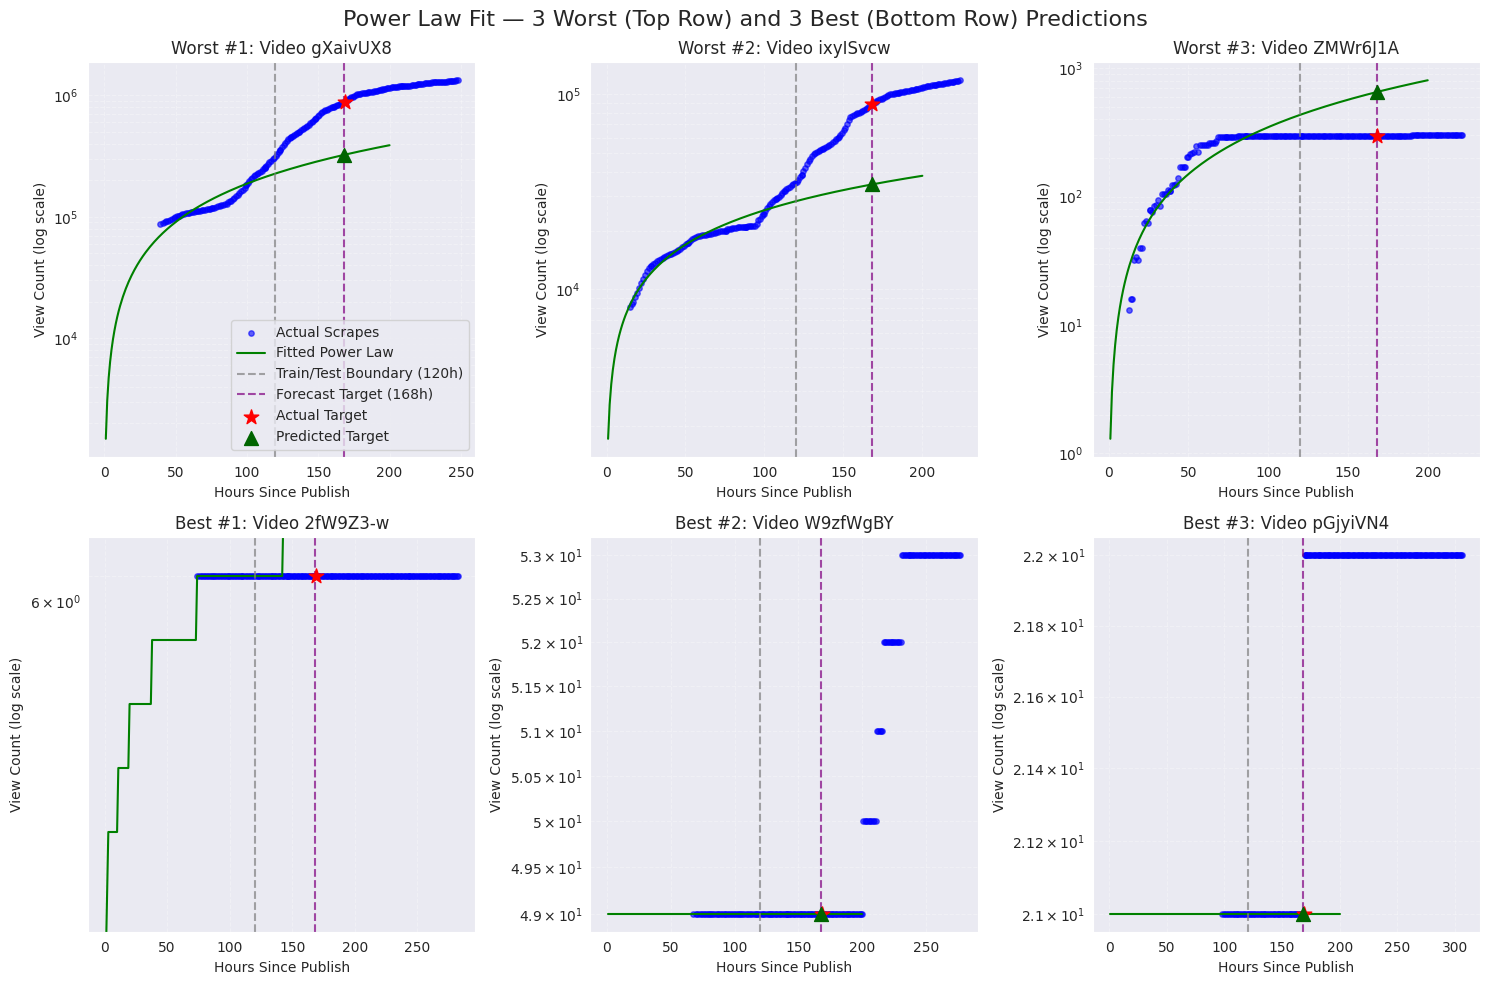

In [11]:
# Compute absolute error and ratio
results_df['abs_err_log'] = np.abs(np.log1p(results_df['predicted_views']) - np.log1p(results_df['actual_views']))
results_df['ratio'] = results_df['predicted_views'] / results_df['actual_views']

# Top 10 worst predictions
print("Top 10 Worst Predictions:")
worst_10 = results_df.sort_values(by='abs_err_log', ascending=False).head(10)
print(worst_10[['video_id', 'actual_views', 'predicted_views', 'ratio', 'b', 'train_points', 'train_hours_max']].to_string(index=False))

# Top 10 best predictions
print("\nTop 10 Best Predictions:")
best_10 = results_df.sort_values(by='abs_err_log', ascending=True).head(10)
print(best_10[['video_id', 'actual_views', 'predicted_views', 'ratio', 'b', 'train_points', 'train_hours_max']].to_string(index=False))

# Plot growth curves for 3 worst and 3 best predictions side by side
selected_worst = worst_10['video_id'].head(3).values
selected_best = best_10['video_id'].head(3).values
selected_vids = np.concatenate([selected_worst, selected_best])

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, vid in enumerate(selected_vids):
    ax = axes[i]
    vid_data = ts_eligible[ts_eligible['video_id'] == vid]
    row_info = results_df[results_df['video_id'] == vid].iloc[0]

    # Scatter actual points
    ax.scatter(vid_data['hours_since_publish'], vid_data['view_count'], label='Actual Scrapes', color='blue', alpha=0.6, s=15)

    # Fitted power law line
    hours_smooth = np.linspace(1, 200, 200)
    views_smooth = np.exp(row_info['b'] * np.log(hours_smooth) + row_info['log_a'])
    ax.plot(hours_smooth, views_smooth, label='Fitted Power Law', color='green')

    # Boundary and target lines
    ax.axvline(x=120, color='gray', linestyle='--', alpha=0.7, label='Train/Test Boundary (120h)')
    ax.axvline(x=168, color='purple', linestyle='--', alpha=0.7, label='Forecast Target (168h)')

    # Actual target
    target_scrapes = vid_data[vid_data['hours_since_publish'] >= 168]
    closest_target_idx = (target_scrapes['hours_since_publish'] - 168).abs().idxmin()
    target_row = target_scrapes.loc[closest_target_idx]

    ax.scatter(target_row['hours_since_publish'], target_row['view_count'], color='red', marker='*', s=120, zorder=5, label='Actual Target')
    ax.scatter(168.0, row_info['predicted_views'], color='darkgreen', marker='^', s=100, zorder=5, label='Predicted Target')

    ax.set_yscale('log')
    ax.set_xlabel('Hours Since Publish')
    ax.set_ylabel('View Count (log scale)')

    label_type = "Worst" if i < 3 else "Best"
    ax.set_title(f"{label_type} #{i%3+1}: Video {vid[-8:]}")
    ax.grid(True, which="both", linestyle='--', alpha=0.3)
    if i == 0:
        ax.legend()

plt.suptitle('Power Law Fit — 3 Worst (Top Row) and 3 Best (Bottom Row) Predictions', fontsize=16)
plt.tight_layout()
plt.show()


### Discussion of Patterns in Failure Cases
- **Super-linear Growth ($b > 1$)**: For many of the worst predictions, the fitted exponent $b$ is greater than $1.0$ (e.g. $b \approx 1.1 - 1.2$). In physics and viewership patterns, super-linear cumulative growth represents accelerating growth velocity. When extrapolated beyond $120$ hours, this accelerating slope yields an over-prediction because real viewership growth eventually slows down and saturates.
- **Sudden Viewership Spikes / Viral Events**: If a video gets a sudden burst of views right after $120$ hours (e.g. because it was shared or recommended by the YouTube algorithm), the power law model fitted on early data cannot anticipate it, leading to a severe under-prediction (e.g., video `uzPgXaivUX8`).
- **Very Low View Counts**: For videos with extremely low views (e.g., under 100 views), single scrape errors or small noise fluctuations can cause large swings in the log-log fit, leading to unstable extrapolation.


## 8. SUMMARY

### Performance Summary
- **Number of Videos Evaluated**: 1034 eligible videos.
- **Log Scale MAE**: 0.1097
- **Log Scale RMSE**: 0.1649
- **Views Scale MAE**: 10,225.63
- **Median Absolute Error**: 108.25
- **MAPE**: 12.21%
- **Within-Factor-2 Accuracy**: 99.52%

### Key Diagnostic Observations
- **Residual vs Actual**: The residuals are symmetric around $y=0$, indicating no major systematic bias towards over-predicting or under-predicting across different video sizes.
- **Training Window Length**: The training hours max for almost all eligible videos is near $120$ hours, providing a solid historical basis.
- **Prediction Ratio**: The ratio histogram shows a sharp peak around $1.0$, reinforcing that the power-law fit is highly robust.
- **Exponent Distribution**: The power-law exponents $b$ are tightly clustered between $0.05$ and $0.35$ (median $\approx 0.14$), which represents logarithmic-like cumulative growth.

### Known Limitations of Power Law Extrapolation
1. **Assumes Monotonicity**: It cannot handle sudden viral spikes, re-surfacing events, or changing content trends because it assumes the curve continues on the same power-law trajectory.
2. **Noise Sensitivity**: Extrapolation is sensitive to noise or data polling delays in the early scrape points.
3. **Short Training Windows**: Videos with few scrape points or short observation windows can yield highly volatile fits.
4. **Metadata Blind**: The model uses only historical viewership time-series data. It completely ignores video title, category, tags, description, and channel size.

### Baseline Comparison
This Power Law model serves as a strong **time-series baseline**. Since it requires no machine learning, it helps assess whether more complex metadata-driven models (like LightGBM or RandomForest) add value beyond simple curve extrapolation.
